# Titanic 数据探索（EDA）

目标：理解数据特征、发现缺失值、观察特征与生存率的关系

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 1. 加载数据 + 基础信息

In [2]:
# 加载数据
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# 基础信息
print("训练集形状:", train.shape)
print("\n前5行:")
print(train.head())
print("\n数据类型 + 缺失值:")
print(train.info())
print("\n数值特征统计:")
print(train.describe())

训练集形状: (891, 12)

前5行:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0

## 2. 缺失值分析

TODO: 观察哪些列有缺失值，缺失比例多少

In [3]:
# 计算缺失值比例
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例%': missing_percent})
print(missing_df[missing_df['缺失数量'] > 0].sort_values('缺失比例%', ascending=False))

          缺失数量      缺失比例%
Cabin      687  77.104377
Age        177  19.865320
Embarked     2   0.224467


## 3. 目标变量分析（生存率）

In [4]:
# 生存率统计
print("生存情况统计:")
print(train['Survived'].value_counts())
print("\n生存率:", train['Survived'].mean())

# 可视化
plt.figure(figsize=(6, 4))
train['Survived'].value_counts().plot(kind='bar')
plt.title('生存情况分布')
plt.xlabel('是否生存 (0=死亡, 1=生存)')
plt.ylabel('人数')
plt.show()

生存情况统计:
Survived
0    549
1    342
Name: count, dtype: int64

生存率: 0.3838383838383838


<Figure size 600x400 with 1 Axes>

## 4. 特征与生存率关系探索

TODO: 探索不同特征（性别、船舱等级、年龄）与生存率的关系

In [5]:
# 性别 vs 生存率
print("性别 vs 生存率:")
print(train.groupby('Sex')['Survived'].mean())

# 船舱等级 vs 生存率
print("\n船舱等级 vs 生存率:")
print(train.groupby('Pclass')['Survived'].mean())

性别 vs 生存率:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

船舱等级 vs 生存率:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


有 Cabin 信息的样本中，各等级分布：
Pclass
1    176
2     16
3     12
Name: count, dtype: int64

无 Cabin 信息的样本中，各等级分布：
Pclass
1     40
2    168
3    479
Name: count, dtype: int64
家庭规模 vs 生存率:
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


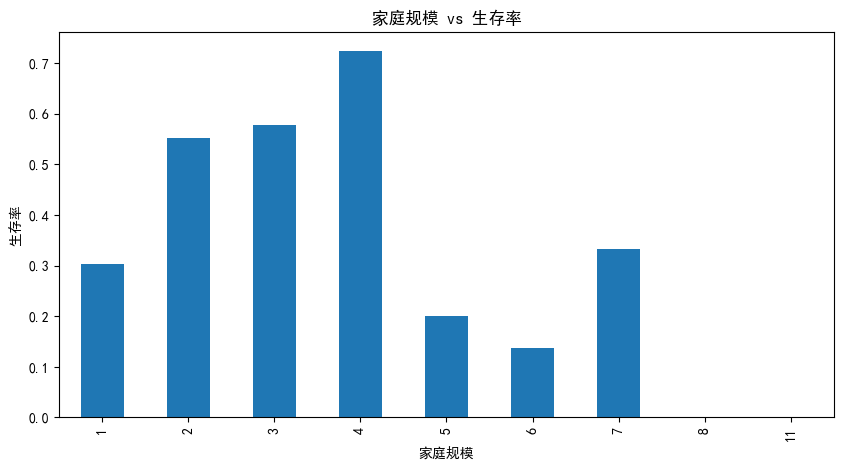

In [6]:
print("有 Cabin 信息的样本中，各等级分布：")
print(train[train['Cabin'].notna()]['Pclass'].value_counts().sort_index())
print("\n无 Cabin 信息的样本中，各等级分布：")
print(train[train['Cabin'].isna()]['Pclass'].value_counts().sort_index())


# 创建家庭规模特征
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# 观察家庭规模与生存率的关系
print("家庭规模 vs 生存率:")
print(train.groupby('FamilySize')['Survived'].mean().sort_index())

# 可视化
plt.figure(figsize=(10, 5))
train.groupby('FamilySize')['Survived'].mean().plot(kind='bar')
plt.title('家庭规模 vs 生存率')
plt.xlabel('家庭规模')
plt.ylabel('生存率')
plt.show()

各组合的年龄中位数:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

各组合的年龄平均值:
Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64


<Figure size 1000x600 with 0 Axes>

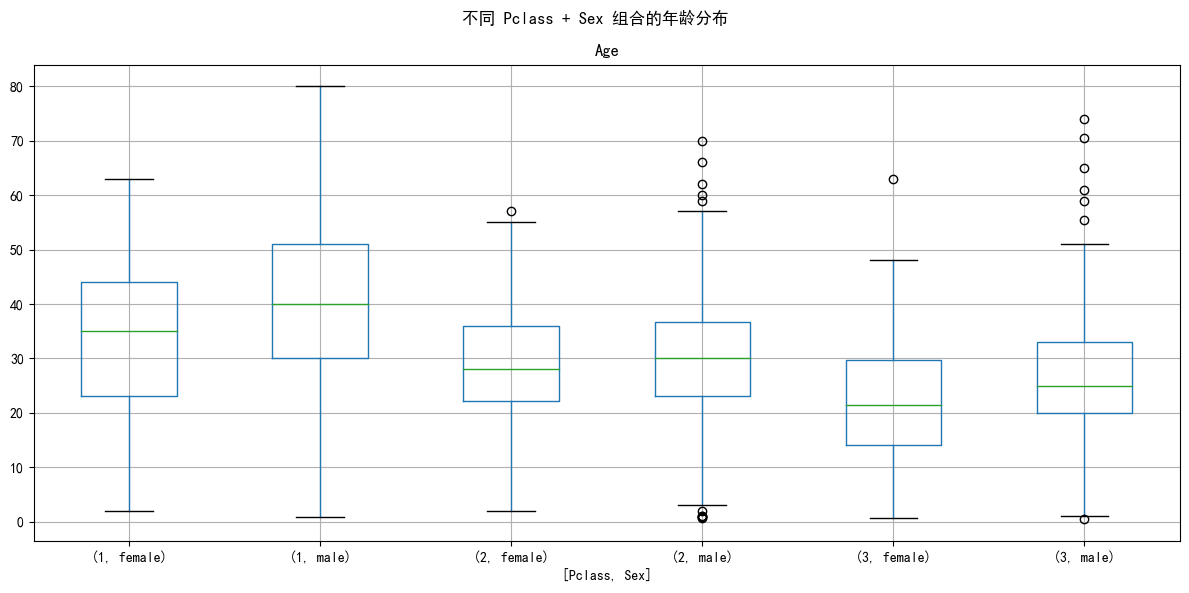

In [7]:
# 观察不同组合的年龄分布
print("各组合的年龄中位数:")
print(train.groupby(['Pclass', 'Sex'])['Age'].median())

print("\n各组合的年龄平均值:")
print(train.groupby(['Pclass', 'Sex'])['Age'].mean())

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
train[train['Age'].notna()].boxplot(column='Age', by=['Pclass', 'Sex'], figsize=(12, 6))
plt.suptitle('不同 Pclass + Sex 组合的年龄分布')
plt.tight_layout()
plt.show()

## 5. 你的观察与发现

运行完上面的代码后，请回答：
1. 哪些特征是数值型、哪些是类别型？
2. 哪些列有缺失值？缺失比例大概多少？
3. 你观察到哪些特征与生存率有明显关系？